# 04 - Benchmark do Pipeline B: ingestão via `.parquet` (uint8)

**Objetivo:** rodar o **mesmo** pipeline de inferência do nb 02, mas lendo os tensores **prontos**
do parquet uint8 (gerado no nb 03) em vez de decodificar `.jpg` em tempo real. Comparar os dois e
mostrar o **GPU Starvation resolvido** + o ganho de throughput.

**Igual ao nb 02** (de propósito, p/ comparação justa): MobileNetV2 forward-only + FP16,
`ResourceMonitor` (CPU/RAM via cgroup), N_ROUNDS + warmup, tetos CPU/GPU, stats e gráficos.

**Decisões de arquitetura (comentadas no código):**
1. **Fonte do dado = parquet uint8**, lido com **pyarrow** e ligado ao `tf.data` via
   `from_generator` + `interleave` (leitura paralela) + `prefetch`. **Não** usamos `tensorflow-io`
   (leitor nativo de parquet): ele arrasta um `tensorflow` que sobrescreveria o TF otimizado da
   NVIDIA (NGC/Blackwell) e quebraria a GPU. E como gravamos bytes uint8, qualquer leitor teria que
   desserializar do mesmo jeito → pyarrow não perde em "limpeza".
2. **Preprocess na GPU:** o parquet guarda pixel cru; o `x/127.5 - 1` do MobileNet roda dentro do
   `infer` (na GPU). A CPU só lê o byte e transfere — e com metade dos bytes (uint8 = 1 vs fp16 = 2).
3. **Cache quente do SO:** o parquet (9,4 GB) cabe quase todo na RAM (16 GB) → leitura quente após a
   1ª rodada. É justo: o jpg re-decodifica a cada rodada; o parquet lê quente — a vantagem que
   queremos mostrar. Disco não é gargalo (34k img/s no nb 02).
4. **`N_IMAGES`:** começa lendo TODAS as imagens do parquet (`None`); troque por um inteiro p/ reduzir.

> Compara com `jpg_forward_stats.csv` (nb 02). Roda no contêiner (2 vCPU / 16 GB).

In [1]:
import os
import time
import threading
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import pynvml
import pyarrow.parquet as pq
import tensorflow as tf

# FP16 (mesma config do nb 02). DEVE vir antes de construir o modelo.
tf.keras.mixed_precision.set_global_policy("mixed_float16")

PARQUET_DIR  = "/tf/data/optimized"      # saida do nb 03 (uint8 224x224x3)
RESULTS_DIR  = Path("/tf/data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 256
N_IMAGES     = None      # None = TODAS as imagens do parquet; um inteiro reduz (controle rapido)
N_PASSES     = 1         # passadas por rodada (suba se reduzir muito o N_IMAGES)
N_ROUNDS     = 3
SAMPLE_EVERY = 1.0
CYCLE        = 2         # arquivos parquet lidos em paralelo (casa com os 2 vCPU)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory_growth:", e)

print("TensorFlow:", tf.__version__, "| policy:", tf.keras.mixed_precision.global_policy().name)

2026-07-01 05:46:46.138874: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 05:46:46.146450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 05:46:46.154282: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 05:46:46.157075: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 05:46:46.163808: I tensorflow/core/platform/cpu_feature_guar

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5060, compute capability 12.0
TensorFlow: 2.17.0 | policy: mixed_float16


I0000 00:00:1782884807.997458    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.024391    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.025581    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.027148    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [2]:
# Inicializa o pynvml p/ monitorar a GPU (igual ao nb 02).
try:
    pynvml.nvmlInit()
    GPU_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
    name = pynvml.nvmlDeviceGetName(GPU_HANDLE)
    print("GPU detectada:", name.decode() if isinstance(name, bytes) else name)
except Exception as e:
    GPU_HANDLE = None
    print("pynvml indisponivel, GPU nao sera monitorada:", e)

GPU detectada: NVIDIA GeForce RTX 5060


In [3]:
# ---------------------------------------------------------------------------
# Ingestao do parquet -> tf.data via PYARROW (nao tensorflow-io).
# ---------------------------------------------------------------------------
# Por que pyarrow e nao tf-io: o `tensorflow-io` tem leitor de parquet nativo, MAS arrasta uma
# dependencia `tensorflow` que sobrescreveria o TF otimizado da NVIDIA (NGC, Blackwell/sm_120)
# -> a RTX 5060 pararia de funcionar. Alem disso, como gravamos a imagem como BYTES uint8, qualquer
# leitor teria que desserializar (`frombuffer`) do mesmo jeito. Ponte via `from_generator` +
# `interleave` (le varios arquivos em paralelo) + `prefetch` -> a CPU entrega milhares de img/s.

PARQUET_FILES = sorted(glob.glob(f"{PARQUET_DIR}/*.parquet"))
if not PARQUET_FILES:
    raise FileNotFoundError(f"Nenhum .parquet em {PARQUET_DIR}. Rode o 03_spark_etl.ipynb antes.")
print(f"Arquivos parquet: {len(PARQUET_FILES)}")


def _parquet_gen(path):
    # Roda numa thread do tf.data; le 1 arquivo em lotes (o Arrow libera o GIL no I/O/deserialize,
    # entao o `interleave` paraleliza de verdade).
    if isinstance(path, bytes):
        path = path.decode()
    pf = pq.ParquetFile(path)
    for b in pf.iter_batches(batch_size=1024, columns=["label", "data"]):
        labels  = b.column("label").to_numpy(zero_copy_only=False)
        buffers = b.column("data").to_pylist()
        for lbl, buf in zip(labels, buffers):
            # bytes uint8 -> tensor (224,224,3). SEM decode de JPEG -> esse e o ganho do Pipeline B.
            yield (np.frombuffer(buf, dtype=np.uint8).reshape(224, 224, 3),
                   np.float32(lbl))


def build_parquet_dataset(batch_size, n_images=None):
    ds = tf.data.Dataset.from_tensor_slices(PARQUET_FILES)
    ds = ds.interleave(
        lambda p: tf.data.Dataset.from_generator(
            _parquet_gen, args=(p,),
            output_signature=(
                tf.TensorSpec(shape=(224, 224, 3), dtype=tf.uint8),
                tf.TensorSpec(shape=(), dtype=tf.float32),
            ),
        ),
        cycle_length=CYCLE,                    # arquivos lidos em paralelo
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False,
    )
    if n_images is not None:
        ds = ds.take(n_images)                 # controle do tamanho (subset)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)         # sobrepoe leitura (CPU) e inferencia (GPU)
    return ds

Arquivos parquet: 35


In [4]:
# Mesmo modelo do nb 02: MobileNetV2 forward-only + FP16.
def build_model():
    base = tf.keras.applications.MobileNetV2(
        weights="imagenet", include_top=False,
        input_shape=(*IMG_SIZE, 3), pooling="avg",
    )
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(base.output)
    return tf.keras.Model(base.input, out)


model = build_model()


@tf.function
def infer(x_uint8):
    # PREPROCESS NA GPU: o parquet entrega pixel cru uint8; o cast + escala ([-1,1]) do MobileNet
    # roda aqui (na GPU). Assim a CPU so leu o byte e transferiu (uint8 = 1 byte, metade do fp16).
    x = tf.cast(x_uint8, tf.float16) / 127.5 - 1.0
    return model(x, training=False)


print("Modelo pronto (MobileNetV2 + FP16, preprocess na GPU). Params:", f"{model.count_params():,}")

I0000 00:00:1782884808.100718    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.102900    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.104077    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782884808.176249    1362 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Modelo pronto (MobileNetV2 + FP16, preprocess na GPU). Params: 2,259,265


In [5]:
# ---------------------------------------------------------------------------
# Monitor de recursos (IDENTICO ao nb 02): CPU/RAM do CONTEINER via cgroup + GPU via pynvml.
# ---------------------------------------------------------------------------
def detect_container_cpu_quota():
    try:
        with open("/sys/fs/cgroup/cpu.max") as f:
            q, p = f.read().strip().split()
        if q != "max":
            return float(q) / float(p)
    except (FileNotFoundError, OSError, ValueError):
        pass
    try:
        with open("/sys/fs/cgroup/cpu/cpu.cfs_quota_us") as f:
            q = int(f.read().strip())
        with open("/sys/fs/cgroup/cpu/cpu.cfs_period_us") as f:
            p = int(f.read().strip())
        if q > 0:
            return q / p
    except (FileNotFoundError, OSError, ValueError):
        pass
    try:
        return float(len(os.sched_getaffinity(0)))
    except (AttributeError, OSError):
        return float(os.cpu_count() or 1)


def read_container_mem():
    try:
        with open("/sys/fs/cgroup/memory.current") as f:
            used = int(f.read().strip())
        with open("/sys/fs/cgroup/memory.max") as f:
            lim = f.read().strip()
        limit = None if lim == "max" else int(lim)
        return used / 1024 ** 3, (limit / 1024 ** 3 if limit else float("nan"))
    except (FileNotFoundError, OSError, ValueError):
        pass
    try:
        with open("/sys/fs/cgroup/memory/memory.usage_in_bytes") as f:
            used = int(f.read().strip())
        with open("/sys/fs/cgroup/memory/memory.limit_in_bytes") as f:
            limit = int(f.read().strip())
        limit = limit if limit < (1 << 62) else None
        return used / 1024 ** 3, (limit / 1024 ** 3 if limit else float("nan"))
    except (FileNotFoundError, OSError, ValueError):
        return float("nan"), float("nan")


N_CONTAINER_CPUS = detect_container_cpu_quota()
_, CONTAINER_MEM_LIMIT_GB = read_container_mem()
print(f"vCPUs (cgroup): {N_CONTAINER_CPUS} | RAM limite (cgroup): {CONTAINER_MEM_LIMIT_GB:.1f} GB")


class ResourceMonitor(threading.Thread):
    def __init__(self, gpu_handle, interval=1.0, n_container_cpus=N_CONTAINER_CPUS):
        super().__init__(daemon=True)
        self.handle = gpu_handle
        self.interval = interval
        self.n_container_cpus = max(float(n_container_cpus), 1e-6)
        self._stop_event = threading.Event()
        self.samples = []
        self.proc = psutil.Process()

    def run(self):
        psutil.cpu_percent(None); self.proc.cpu_percent(None)
        t_start = time.time()
        while not self._stop_event.is_set():
            cpu_host     = psutil.cpu_percent(None)
            proc_cpu_raw = self.proc.cpu_percent(None)
            cpu_container = min(proc_cpu_raw / self.n_container_cpus, 100.0)
            cont_used_gb, _  = read_container_mem()
            proc_rss_gb      = self.proc.memory_info().rss / (1024 ** 3)
            ram_used_host_gb = psutil.virtual_memory().used / (1024 ** 3)
            gpu_util, gpu_mem_gb = np.nan, np.nan
            if self.handle is not None:
                try:
                    gpu_util   = float(pynvml.nvmlDeviceGetUtilizationRates(self.handle).gpu)
                    gpu_mem_gb = pynvml.nvmlDeviceGetMemoryInfo(self.handle).used / (1024 ** 3)
                except Exception:
                    pass
            self.samples.append({
                "t_rel": time.time() - t_start, "cpu_pct": cpu_container, "cpu_pct_host": cpu_host,
                "proc_cpu_raw": proc_cpu_raw, "cont_mem_used_gb": cont_used_gb,
                "proc_rss_gb": proc_rss_gb, "ram_used_host_gb": ram_used_host_gb,
                "gpu_util_pct": gpu_util, "gpu_mem_gb": gpu_mem_gb,
            })
            self._stop_event.wait(self.interval)

    def stop(self):
        self._stop_event.set(); self.join()
        return pd.DataFrame(self.samples)

vCPUs (cgroup): 2.0 | RAM limite (cgroup): 16.0 GB


In [6]:
round_summaries, raw_samples = [], []

# Warmup FORA do cronometro (traca o infer + esquenta cache/pipeline) -> rodada 1 nao infla o desvio.
_ds_warm = build_parquet_dataset(BATCH_SIZE, N_IMAGES)
for x, _ in _ds_warm.take(5):
    infer(x)

for r in range(1, N_ROUNDS + 1):
    print(f"\n===== Rodada {r}/{N_ROUNDS} =====")
    ds = build_parquet_dataset(BATCH_SIZE, N_IMAGES)   # le o parquet (cache quente apos a rodada 1)

    monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
    monitor.start()
    n_images = 0
    t0 = time.time()
    for _ in range(N_PASSES):
        for x, y in ds:
            infer(x)                                   # forward (preprocess na GPU)
            n_images += int(x.shape[0])
    elapsed = time.time() - t0
    df_s = monitor.stop(); df_s["round"] = r; raw_samples.append(df_s)

    tp = n_images / elapsed
    round_summaries.append({
        "round": r, "n_images": n_images, "round_time_s": elapsed, "throughput_img_s": tp,
        "cpu_mean_pct": df_s["cpu_pct"].mean(), "cpu_max_pct": df_s["cpu_pct"].max(),
        "cont_mem_peak_gb": df_s["cont_mem_used_gb"].max(), "proc_rss_peak_gb": df_s["proc_rss_gb"].max(),
        "ram_host_peak_gb": df_s["ram_used_host_gb"].max(),
        "gpu_util_mean_pct": df_s["gpu_util_pct"].mean(), "gpu_util_max_pct": df_s["gpu_util_pct"].max(),
        "gpu_mem_peak_gb": df_s["gpu_mem_gb"].max(),
    })
    s = round_summaries[-1]
    print(f"  imagens={n_images:,} | tempo={elapsed:.1f}s | throughput={tp:.1f} img/s | "
          f"CPU={s['cpu_mean_pct']:.0f}% | GPU={s['gpu_util_mean_pct']:.0f}%")

summary_df = pd.DataFrame(round_summaries)
raw_df = pd.concat(raw_samples, ignore_index=True)
summary_df

2026-07-01 05:46:50.258892: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-01 05:46:50.296199: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1782884810.329387    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884810.330364    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884810.331362    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884810.332501    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884810.336706    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884810.340194    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement 


===== Rodada 1/3 =====


W0000 00:00:1782884816.036784    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.038739    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.039537    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.040528    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.042310    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.046077    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.049722    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.056475    1425 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884816.061807    1425 gp

  imagens=70,433 | tempo=21.7s | throughput=3249.7 img/s | CPU=86% | GPU=94%

===== Rodada 2/3 =====


W0000 00:00:1782884857.520041    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.520170    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.520290    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.520459    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.520707    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.521174    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.521688    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.522675    1427 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1782884857.523419    1427 gp

  imagens=70,433 | tempo=20.9s | throughput=3365.6 img/s | CPU=87% | GPU=92%

===== Rodada 3/3 =====
  imagens=70,433 | tempo=21.4s | throughput=3289.3 img/s | CPU=85% | GPU=91%


2026-07-01 05:47:59.225347: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,round,n_images,round_time_s,throughput_img_s,cpu_mean_pct,cpu_max_pct,cont_mem_peak_gb,proc_rss_peak_gb,ram_host_peak_gb,gpu_util_mean_pct,gpu_util_max_pct,gpu_mem_peak_gb
0,1,70433,21.673921,3249.665792,85.595455,95.95,15.979000,7.358887,17.480068,94.136364,100.0,4.013428
1,2,70433,20.927145,3365.628708,86.716667,98.45,15.984081,8.364021,18.434093,91.761905,100.0,4.010193
2,3,70433,21.412519,3289.337387,84.538636,95.45,15.998787,7.804276,18.202168,91.227273,100.0,3.949707


In [7]:
# Tetos isolados (mesma logica do nb 02) -> quantifica o starvation deste pipeline.
x_fixed, _ = next(iter(build_parquet_dataset(BATCH_SIZE, N_IMAGES)))
infer(x_fixed)                                   # warmup do teste de GPU
N_STEPS = max(30, 15000 // BATCH_SIZE)

cpu_ceils, gpu_ceils = [], []
for r in range(1, N_ROUNDS + 1):
    # TETO CPU: leitura+deserializacao do parquet, SEM modelo (produtor)
    ds_cpu = build_parquet_dataset(BATCH_SIZE, N_IMAGES)
    n, t0 = 0, time.time()
    for _ in range(N_PASSES):
        for x, y in ds_cpu:
            n += int(x.shape[0])
    cpu_ceils.append(n / (time.time() - t0))
    # TETO GPU: forward sobre 1 batch fixo uint8 (consumidor) -> deve bater ~o do nb 02 (mesmo modelo)
    n, t0 = 0, time.time()
    for _ in range(N_STEPS):
        infer(x_fixed)
        n += int(x_fixed.shape[0])
    gpu_ceils.append(n / (time.time() - t0))
    print(f"  rodada {r}: teto CPU(leitura)={cpu_ceils[-1]:.0f} | teto GPU={gpu_ceils[-1]:.0f} img/s")

cpu_ceiling = float(np.mean(cpu_ceils)); cpu_ceiling_std = float(np.std(cpu_ceils, ddof=1)) if N_ROUNDS > 1 else 0.0
gpu_ceiling = float(np.mean(gpu_ceils)); gpu_ceiling_std = float(np.std(gpu_ceils, ddof=1)) if N_ROUNDS > 1 else 0.0
print(f"\nTeto CPU (leitura parquet): {cpu_ceiling:.0f} +/- {cpu_ceiling_std:.0f} img/s  (produtor)")
print(f"Teto GPU (forward)        : {gpu_ceiling:.0f} +/- {gpu_ceiling_std:.0f} img/s  (consumidor)")

  rodada 1: teto CPU(leitura)=6418 | teto GPU=3663 img/s
  rodada 2: teto CPU(leitura)=6261 | teto GPU=3646 img/s
  rodada 3: teto CPU(leitura)=6313 | teto GPU=3660 img/s

Teto CPU (leitura parquet): 6331 +/- 80 img/s  (produtor)
Teto GPU (forward)        : 3656 +/- 9 img/s  (consumidor)


In [8]:
tp = summary_df["throughput_img_s"].values
tp_mean = float(tp.mean()); tp_std = float(tp.std(ddof=1)) if len(tp) > 1 else 0.0
gpu_waste_pct = 100.0 * (1 - tp_mean / gpu_ceiling) if gpu_ceiling else float("nan")

stats = {
    "pipeline": "parquet_uint8_forward",
    "n_rounds": N_ROUNDS, "batch_size": BATCH_SIZE,
    "n_images_round": int(summary_df["n_images"].iloc[0]),
    "throughput_mean_img_s": tp_mean, "throughput_std_img_s": tp_std,
    "cpu_ceiling_img_s": cpu_ceiling, "cpu_ceiling_std_img_s": cpu_ceiling_std,
    "gpu_ceiling_img_s": gpu_ceiling, "gpu_ceiling_std_img_s": gpu_ceiling_std,
    "gpu_waste_pct": gpu_waste_pct,
    "round_time_mean_s": float(summary_df["round_time_s"].mean()),
    "cpu_mean_pct": float(summary_df["cpu_mean_pct"].mean()),
    "gpu_util_mean_pct": float(summary_df["gpu_util_mean_pct"].mean()),
    "cont_mem_peak_gb": float(summary_df["cont_mem_peak_gb"].max()),
    "gpu_mem_peak_gb": float(summary_df["gpu_mem_peak_gb"].max()),
}
stats_df = pd.DataFrame([stats])
summary_df.to_csv(RESULTS_DIR / "parquet_forward_per_round.csv", index=False)
stats_df.to_csv(RESULTS_DIR / "parquet_forward_stats.csv", index=False)
raw_df.to_csv(RESULTS_DIR / "parquet_forward_raw_samples.csv", index=False)

print(f"Teto CPU (leitura)  : {cpu_ceiling:.0f} +/- {cpu_ceiling_std:.0f} img/s   (produtor)")
print(f"Teto GPU (forward)  : {gpu_ceiling:.0f} +/- {gpu_ceiling_std:.0f} img/s   (consumidor)")
print(f"Pipeline parquet    : {tp_mean:.0f} +/- {tp_std:.0f} img/s")
print(f">> GPU desperdicada : {gpu_waste_pct:.0f}%  (starvation)")
print(f"GPU util {stats['gpu_util_mean_pct']:.0f}% | CPU {stats['cpu_mean_pct']:.0f}% | "
      f"RAM {stats['cont_mem_peak_gb']:.2f}/{CONTAINER_MEM_LIMIT_GB:.1f} GB")
stats_df

Teto CPU (leitura)  : 6331 +/- 80 img/s   (produtor)
Teto GPU (forward)  : 3656 +/- 9 img/s   (consumidor)
Pipeline parquet    : 3302 +/- 59 img/s
>> GPU desperdicada : 10%  (starvation)
GPU util 92% | CPU 86% | RAM 16.00/16.0 GB


,pipeline,n_rounds,batch_size,n_images_round,throughput_mean_img_s,throughput_std_img_s,cpu_ceiling_img_s,cpu_ceiling_std_img_s,gpu_ceiling_img_s,gpu_ceiling_std_img_s,gpu_waste_pct,round_time_mean_s,cpu_mean_pct,gpu_util_mean_pct,cont_mem_peak_gb,gpu_mem_peak_gb
0,parquet_uint8_forward,3,256,70433,3301.543962,58.937253,6330.842059,79.675768,3656.149738,9.403527,9.698885,21.337862,85.616919,92.37518,15.998787,4.013428


## Comparação final: `.jpg` (Pipeline A) vs `.parquet` (Pipeline B)

Carrega o `jpg_forward_stats.csv` (nb 02) e compara throughput, utilização e starvation — o
resultado que prova a tese (decode movido pro ETL → CPU liberada → GPU alimentada).

                 metrica     jpg (A)  parquet (B)  delta
      throughput (img/s) 2432.889639  3301.543962  1.36x
            GPU util (%)   76.629656    92.375180 +16 pp
            CPU util (%)   92.181987    85.616919  -7 pp
teto CPU/leitura (img/s) 2760.659282  6330.842059  2.29x
    GPU desperdicada (%)   27.256097     9.698885 -18 pp


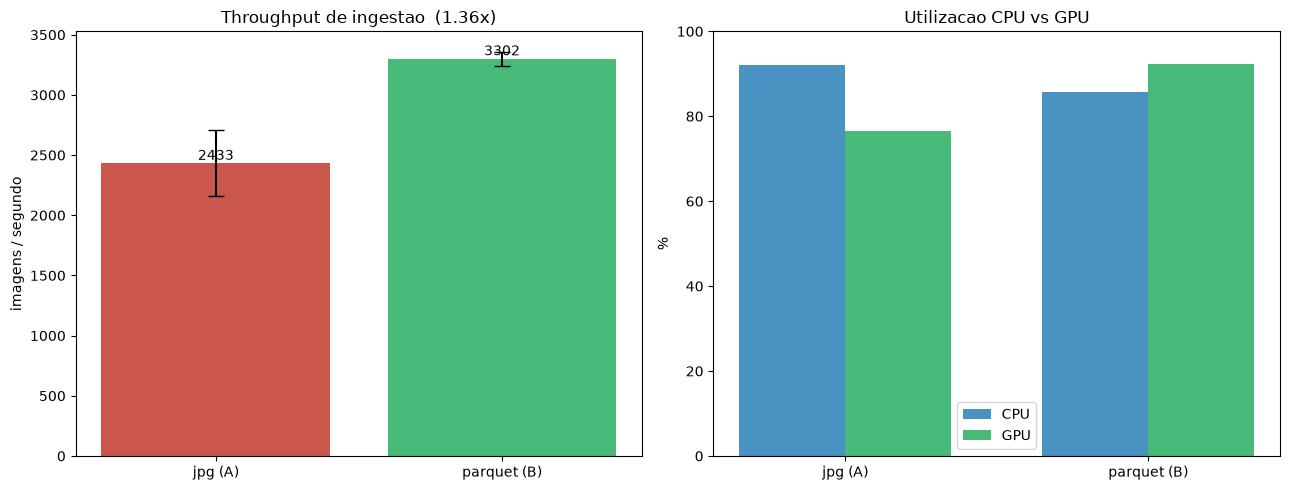

In [9]:
jpg_csv = RESULTS_DIR / "jpg_forward_stats.csv"
if not jpg_csv.exists():
    print(f"[!] {jpg_csv} nao encontrado. Rode o nb 02 (jpg_forward) antes p/ a comparacao.")
else:
    jpg = pd.read_csv(jpg_csv).iloc[0]
    speedup = tp_mean / jpg["throughput_mean_img_s"]
    cmp = pd.DataFrame({
        "metrica": ["throughput (img/s)", "GPU util (%)", "CPU util (%)",
                    "teto CPU/leitura (img/s)", "GPU desperdicada (%)"],
        "jpg (A)": [jpg["throughput_mean_img_s"], jpg["gpu_util_mean_pct"], jpg["cpu_mean_pct"],
                    jpg["cpu_ceiling_img_s"], jpg["gpu_waste_pct"]],
        "parquet (B)": [tp_mean, stats["gpu_util_mean_pct"], stats["cpu_mean_pct"],
                        cpu_ceiling, gpu_waste_pct],
        "delta": [f"{speedup:.2f}x",
                  f"{stats['gpu_util_mean_pct'] - jpg['gpu_util_mean_pct']:+.0f} pp",
                  f"{stats['cpu_mean_pct'] - jpg['cpu_mean_pct']:+.0f} pp",
                  f"{cpu_ceiling / jpg['cpu_ceiling_img_s']:.2f}x",
                  f"{gpu_waste_pct - jpg['gpu_waste_pct']:+.0f} pp"],
    })
    print(cmp.to_string(index=False))
    cmp.to_csv(RESULTS_DIR / "comparacao_jpg_vs_parquet.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    ax.bar(["jpg (A)", "parquet (B)"], [jpg["throughput_mean_img_s"], tp_mean],
           yerr=[jpg["throughput_std_img_s"], tp_std], capsize=6,
           color=["#c0392b", "#27ae60"], alpha=0.85)
    ax.set_title(f"Throughput de ingestao  ({speedup:.2f}x)")
    ax.set_ylabel("imagens / segundo")
    for i, v in enumerate([jpg["throughput_mean_img_s"], tp_mean]):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")

    ax = axes[1]
    x = np.arange(2); w = 0.35
    ax.bar(x - w/2, [jpg["cpu_mean_pct"], stats["cpu_mean_pct"]], w, label="CPU", color="#2980b9", alpha=0.85)
    ax.bar(x + w/2, [jpg["gpu_util_mean_pct"], stats["gpu_util_mean_pct"]], w, label="GPU", color="#27ae60", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(["jpg (A)", "parquet (B)"]); ax.set_ylim(0, 100)
    ax.set_title("Utilizacao CPU vs GPU"); ax.set_ylabel("%"); ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "comparacao_jpg_vs_parquet.png", dpi=120, bbox_inches="tight")
    plt.show()